In [1]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)

2026-04-02 16:00:16,993 - tornado.application - ERROR - Exception in callback functools.partial(<function TCPServer._handle_connection.<locals>.<lambda> at 0x7f48dac813a0>, <Task finished name='Task-8437823' coro=<BaseTCPListener._handle_stream() done, defined at /home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/distributed/comm/tcp.py:655> exception=MemoryError((7002586286238287176,), dtype('uint8'))>)
Traceback (most recent call last):
  File "/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/tornado/tcpserver.py", line 387, in <lambda>
    gen.convert_yielded(future), lambda f: f.result()
                                           ^^^^^^^^^^
  File "/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/distributed/comm/tcp.py", line 667, in _handle_stream
    await self.o

In [2]:
foldername = '/home/edavenport/analysis/vel-assim-manuscript/assimilation_results/spectra/'

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13
import cmocean.cm as cmo
import xarray as xr
from open_tpose import tpose2012to2013
import numpy as np
import xarray as xr
from xmitgcm import open_mdsdataset

prefix = ['diag_state','diag_surf']
ds_tpose_noTAO = tpose2012to2013(prefix)

ds_tpose_noTAO['XC'] = ds_tpose_noTAO.XC.astype(float)
ds_tpose_noTAO['YC'] = ds_tpose_noTAO.YC.astype(float)
ds_tpose_noTAO['Z'] = ds_tpose_noTAO.Z.astype(float)
ds_tpose_noTAO['XG'] = ds_tpose_noTAO.XG.astype(float)
ds_tpose_noTAO['YC'] = ds_tpose_noTAO.YC.astype(float)

data_dir = '/data/SO3/edavenport/tpose6/sep2012/velocity_assim/run_iter22/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

offset = 10
num_diags = 30+31+offset #sep, oct + 10 days
itPerFile = 72 # 1 day
intervals = range(itPerFile,itPerFile*num_diags,itPerFile)

ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-08-31 12:00:00',delta_t=1200)

num_diags = 30+31+offset# nov, dec (starting from nov 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/nov2012/run_iter20/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-10-31 12:00:00',delta_t=1200)

ds_tpose_TAO = xr.concat([ds,ds_new],dim='time')

num_diags = 31+28+offset # jan, feb, (starting from jan 10) # add + offset to continue
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/jan2013/run_iter14/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-12-31 12:00:00',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

num_diags = 31+30+31+30+1 # mar, apr, may, june (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/mar2013/run_iter16/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-03-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

ds_tpose_TAO['XC'] = ds_tpose_TAO.XC.astype(float)
ds_tpose_TAO['YC'] = ds_tpose_TAO.YC.astype(float)
ds_tpose_TAO['Z'] = ds_tpose_TAO.Z.astype(float)
ds_tpose_TAO['XG'] = ds_tpose_TAO.XG.astype(float)
ds_tpose_TAO['YC'] = ds_tpose_TAO.YC.astype(float)

mar2013/diags_daily/
may2013/diags_daily/
jul2013/diags_daily/
sep2013/diags_daily/
nov2013/diags_daily/
Days in 2012-2013: (should be 731)
731


In [4]:
ds_tpose_noTAO = ds_tpose_noTAO.sel(time=slice('2012-09-01','2013-06-30'))

In [41]:
def psd_for_plot_2d(data_array):
    # --- time spacing in seconds ---
    dt = (data_array.time[1] - data_array.time[0]).values / np.timedelta64(1, 's')
    fs = 1.0 / dt                     # sampling frequency (Hz)
    N = len(data_array)
    window = np.hanning(N)

    data_detrended = (data_array - data_array.mean(dim='time'))
    data_windowed = data_detrended * window[:,np.newaxis]
    fft_values = np.fft.rfft(data_windowed,axis=0)

    # --- PSD normalization ---
    U = (window**2).sum()       # window power
    psd_hz = (np.abs(fft_values) ** 2) / (U * fs)
    psd_hz[1:-1] *= 2 # variance preserving spectra
    psd_cpd = psd_hz / 86400

    freq_hz = np.fft.rfftfreq(N, d=dt)
    freq_dpc = 1/(freq_hz * 86400)        # cycles per day
    psd_dpc = psd_cpd / (freq_dpc[:,np.newaxis]**2)
    
    return fft_values, psd_hz, psd_dpc, freq_hz, freq_dpc

def psd_for_plot_1d(data_array):
    # --- time spacing in seconds ---
    dt = (data_array.time[1] - data_array.time[0]).values / np.timedelta64(1, 's')
    fs = 1.0 / dt                     # sampling frequency (Hz)
    N = len(data_array)
    window = np.hanning(N)

    data_detrended = (data_array - data_array.mean(dim='time'))
    data_windowed = data_detrended * window
    fft_values = np.fft.rfft(data_windowed,axis=0)

    # --- PSD normalization ---
    U = (window**2).sum()       # window power
    psd_hz = (np.abs(fft_values) ** 2) / (U * fs)
    psd_hz[1:-1] *= 2 # variance preserving spectra
    psd_cpd = psd_hz / 86400
    freq_hz = np.fft.rfftfreq(N, d=dt)
    freq_dpc = 1/(freq_hz * 86400)        # cycles per day
    psd_dpc = psd_cpd / (freq_dpc**2)
    
    return fft_values, psd_hz, psd_dpc, freq_hz, freq_dpc

In [32]:
import numba
import xgcm 
grid = xgcm.Grid(ds_tpose_TAO, periodic=False)
UVEL = grid.interp(ds_tpose_TAO.UVEL, 'X', boundary='fill')
grid = xgcm.Grid(ds_tpose_noTAO, periodic=False)
UVEL_noTAO = grid.interp(ds_tpose_noTAO.UVEL, 'X', boundary='fill')

In [27]:
grid = xgcm.Grid(ds_tpose_TAO, periodic=False)
VVEL = grid.interp(ds_tpose_TAO.VVEL, 'Y', boundary='fill')
grid = xgcm.Grid(ds_tpose_noTAO, periodic=False)
VVEL_noTAO = grid.interp(ds_tpose_noTAO.VVEL, 'Y', boundary='fill')

In [74]:
def integrated_power_spectrum(lon):
    _, _, psd, _, freq_dpc = psd_for_plot_2d(UVEL.sel(YC=0,XC=lon,method='nearest').sel(Z=slice(0,-300)))
    _, _, psd_noTAO, _, freq_dpc = psd_for_plot_2d(UVEL_noTAO.sel(YC=0,XC=lon,method='nearest').sel(Z=slice(0,-300)))
    z_levels = UVEL.sel(YC=0, XC=lon, method='nearest').sel(Z=slice(0,-300)).Z.values

    psd_u = xr.DataArray(
        psd,
        dims=['freq', 'Z'],
        coords={
            'freq': freq_dpc,
            'Z': z_levels
        }
    )

    psd_u_noTAO = xr.DataArray(
        psd_noTAO,
        dims=['freq', 'Z'],
        coords={
            'freq': freq_dpc,
            'Z': z_levels
        }
    )

    _, _, psd, _, freq_dpc = psd_for_plot_2d(VVEL.sel(YC=0,XC=lon,method='nearest').sel(Z=slice(0,-300)))
    _, _, psd_noTAO, _, freq_dpc = psd_for_plot_2d(VVEL_noTAO.sel(YC=0,XC=lon,method='nearest').sel(Z=slice(0,-300)))
    z_levels = VVEL.sel(YC=0, XC=lon, method='nearest').sel(Z=slice(0,-300)).Z.values

    psd_v = xr.DataArray(
        psd,
        dims=['freq', 'Z'],
        coords={
            'freq': freq_dpc,
            'Z': z_levels
        }
    )

    psd_v_noTAO = xr.DataArray(
        psd_noTAO,
        dims=['freq', 'Z'],
        coords={
            'freq': freq_dpc,
            'Z': z_levels
        }
    )

    P_int_u = (psd_u * ds_tpose_TAO.sel(Z=slice(0,-300)).drF).sum('Z')  # units: [X² m / Hz]
    P_int_u_noTAO = (psd_u_noTAO * ds_tpose_noTAO.sel(Z=slice(0,-300))['drF']).sum('Z')  # units: [X² m / Hz]
    P_int_v = (psd_v * ds_tpose_TAO.sel(Z=slice(0,-300))['drF']).sum('Z')  # units: [X² m / Hz]
    P_int_v_noTAO = (psd_v_noTAO * ds_tpose_noTAO.sel(Z=slice(0,-300))['drF']).sum('Z')  # units: [X² m / Hz]

    return P_int_u, P_int_u_noTAO, P_int_v, P_int_v_noTAO, freq_dpc

/tmp/ipykernel_715397/3788316874.py:19: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_715397/3788316874.py:19: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_715397/3788316874.py:19: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_715397/3788316874.py:19: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_715397/3788316874.py:19: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_715397/3788316874.py:19: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_715397/3788316874.py:19: RuntimeWarning: divide by zero encountered in divide
  freq_

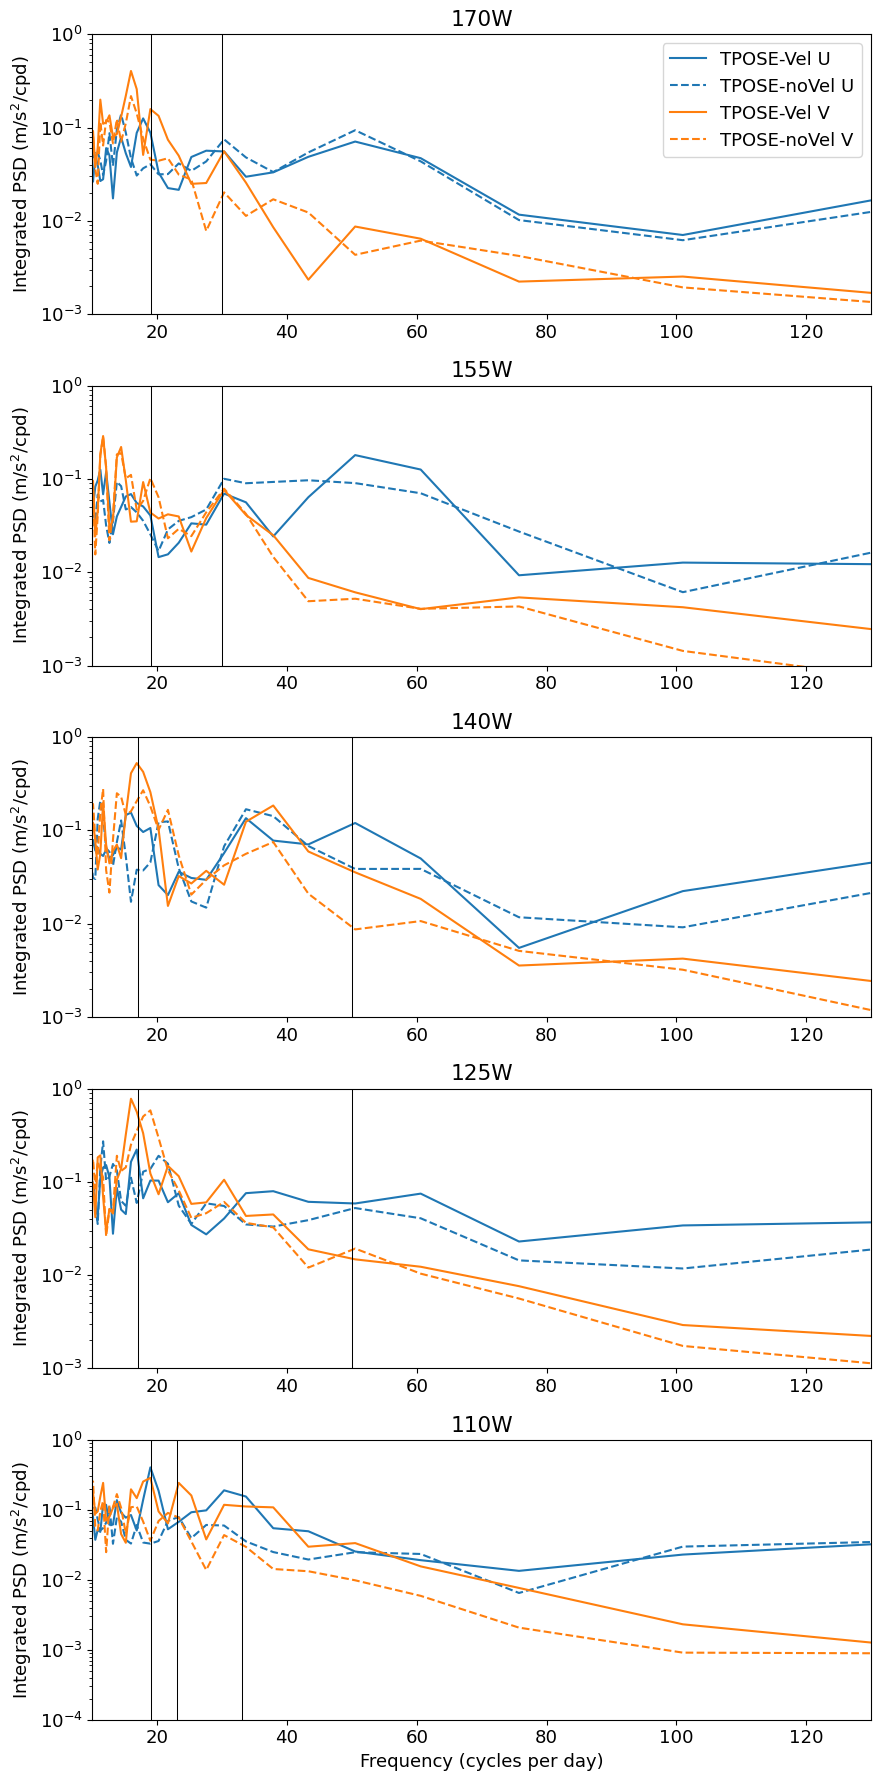

In [79]:
fig, ax = plt.subplots(figsize=(9,18),nrows=5)

P_int_u, P_int_u_noTAO, P_int_v, P_int_v_noTAO, freq_dpc = integrated_power_spectrum(190.0)
ax[0].plot(freq_dpc, P_int_u,color='tab:blue',label='TPOSE-Vel U')
ax[0].plot(freq_dpc, P_int_u_noTAO,color='tab:blue',ls='--',label='TPOSE-noVel U')
ax[0].plot(freq_dpc, P_int_v,color='tab:orange',label='TPOSE-Vel V')
ax[0].plot(freq_dpc, P_int_v_noTAO,color='tab:orange',ls='--',label='TPOSE-noVel V')
ax[0].legend()
ax[0].axvline(19,color='k',lw=0.75)
ax[0].axvline(30,color='k',lw=0.75)
ax[0].set_xlabel('')
ax[0].set_ylabel('Integrated PSD (m/s$^2$/cpd)')
ax[0].set_title('170W')
ax[0].semilogy()
ax[0].set_xlim(10,130)
ax[0].set_ylim(1e-3,1e0)

P_int_u, P_int_u_noTAO, P_int_v, P_int_v_noTAO, freq_dpc = integrated_power_spectrum(205.0)
ax[1].plot(freq_dpc, P_int_u,color='tab:blue',label='TPOSE-Vel U')
ax[1].plot(freq_dpc, P_int_u_noTAO,color='tab:blue',ls='--',label='TPOSE-noVel U')
ax[1].plot(freq_dpc, P_int_v,color='tab:orange',label='TPOSE-Vel V')
ax[1].plot(freq_dpc, P_int_v_noTAO,color='tab:orange',ls='--',label='TPOSE-noVel V')
# ax[1].legend()
ax[1].axvline(19,color='k',lw=0.75)
ax[1].axvline(30,color='k',lw=0.75)
ax[1].set_xlabel('')
ax[1].set_ylabel('Integrated PSD (m/s$^2$/cpd)')
ax[1].set_title('155W')
ax[1].semilogy()
ax[1].set_xlim(10,130)
ax[1].set_ylim(1e-3,1e0)

P_int_u, P_int_u_noTAO, P_int_v, P_int_v_noTAO, freq_dpc = integrated_power_spectrum(220.0)
ax[2].plot(freq_dpc, P_int_u,color='tab:blue',label='TPOSE-Vel U')
ax[2].plot(freq_dpc, P_int_u_noTAO,color='tab:blue',ls='--',label='TPOSE-noVel U')
ax[2].plot(freq_dpc, P_int_v,color='tab:orange',label='TPOSE-Vel V')
ax[2].plot(freq_dpc, P_int_v_noTAO,color='tab:orange',ls='--',label='TPOSE-noVel V')
# ax[2].legend()
ax[2].axvline(17,color='k',lw=0.75)
ax[2].axvline(50,color='k',lw=0.75)
ax[2].set_xlabel('')
ax[2].set_ylabel('Integrated PSD (m/s$^2$/cpd)')
ax[2].set_title('140W')
ax[2].semilogy()
ax[2].set_xlim(10,130)
ax[2].set_ylim(1e-3,1e0)

P_int_u, P_int_u_noTAO, P_int_v, P_int_v_noTAO, freq_dpc = integrated_power_spectrum(235.0)
ax[3].plot(freq_dpc, P_int_u,color='tab:blue',label='TPOSE-Vel U')
ax[3].plot(freq_dpc, P_int_u_noTAO,color='tab:blue',ls='--',label='TPOSE-noVel U')
ax[3].plot(freq_dpc, P_int_v,color='tab:orange',label='TPOSE-Vel V')
ax[3].plot(freq_dpc, P_int_v_noTAO,color='tab:orange',ls='--',label='TPOSE-noVel V')
# ax[3].legend()
ax[3].axvline(17,color='k',lw=0.75)
ax[3].axvline(50,color='k',lw=0.75)
ax[3].set_xlabel('')
ax[3].set_ylabel('Integrated PSD (m/s$^2$/cpd)')
ax[3].set_title('125W')
ax[3].semilogy()
ax[3].set_xlim(10,130)
ax[3].set_ylim(1e-3,1e0)

P_int_u, P_int_u_noTAO, P_int_v, P_int_v_noTAO, freq_dpc = integrated_power_spectrum(250.0)
ax[4].plot(freq_dpc, P_int_u,color='tab:blue',label='TPOSE-Vel U')
ax[4].plot(freq_dpc, P_int_u_noTAO,color='tab:blue',ls='--',label='TPOSE-noVel U')
ax[4].plot(freq_dpc, P_int_v,color='tab:orange',label='TPOSE-Vel V')
ax[4].plot(freq_dpc, P_int_v_noTAO,color='tab:orange',ls='--',label='TPOSE-noVel V')
# ax[4].legend()
ax[4].axvline(19,color='k',lw=0.75)
ax[4].axvline(23,color='k',lw=0.75)
ax[4].axvline(33,color='k',lw=0.75)
ax[4].set_xlabel('Frequency (cycles per day)')
ax[4].set_ylabel('Integrated PSD (m/s$^2$/cpd)')
ax[4].set_title('110W')
ax[4].semilogy()
ax[4].set_xlim(10,130)
ax[4].set_ylim(1e-4,1e0)

plt.tight_layout()
fig.savefig(foldername + 'integrated_power_spectrum_5lon.png',dpi=300)

/tmp/ipykernel_715397/3788316874.py:19: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_715397/3788316874.py:19: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_715397/3788316874.py:19: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_715397/3788316874.py:19: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_715397/3788316874.py:19: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_715397/3788316874.py:19: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_715397/3788316874.py:19: RuntimeWarning: divide by zero encountered in divide
  freq_

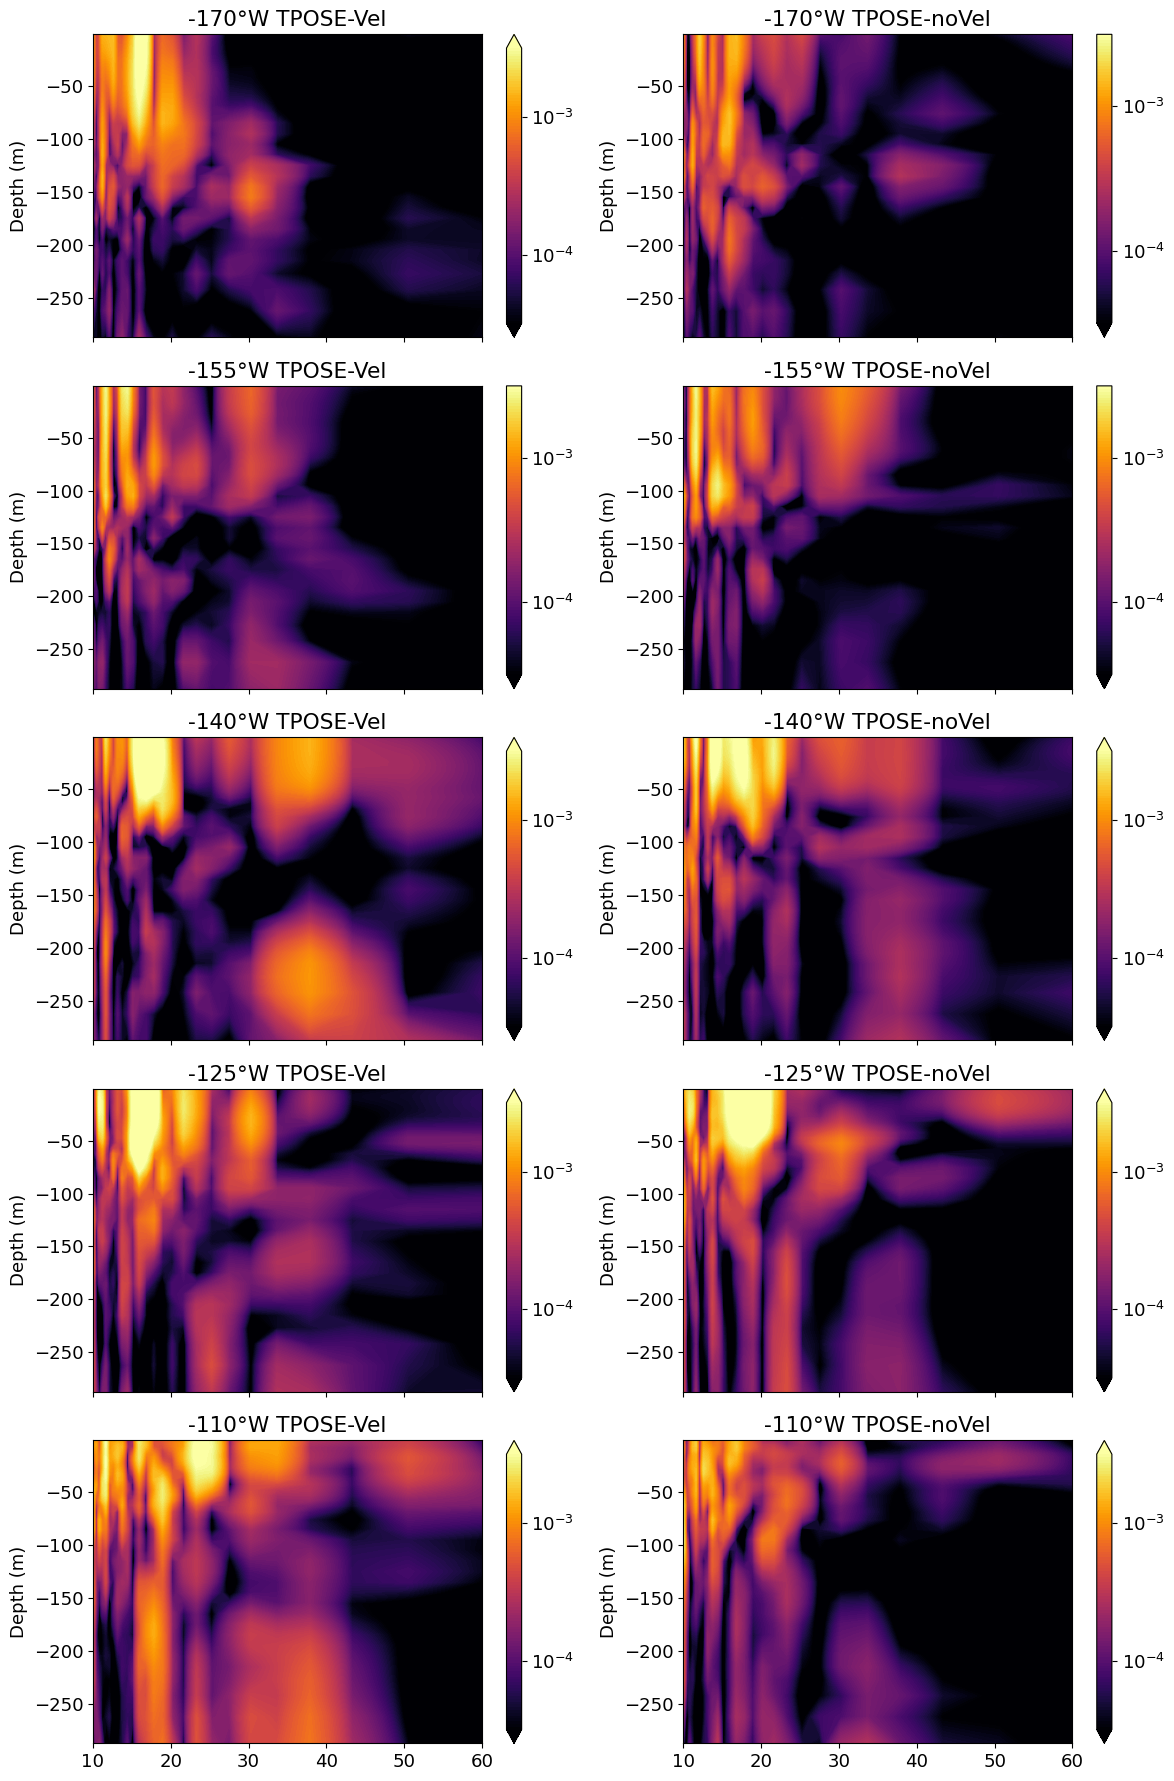

In [94]:
from matplotlib.colors import LogNorm
from matplotlib import ticker
lons = [190.0, 205.0, 220.0, 235.0, 250.0]
cbar_kwargs={
        'ticks': ticker.LogLocator(base=10, subs=[1.0]),  # ticks at 10^n
        'format': ticker.LogFormatterMathtext(),           # renders as 10^n
    }
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 18), sharex=True)
# log_levels = np.logspace(-5, -2, 50)
# norm = LogNorm(vmin=vmin, vmax=vmax)
# levels = np.linspace(1e-5,1e-3,100)
levels = np.logspace(-4.5, -2.5, 100)

for lon, ax in zip(lons,axes.flatten()[::2]):
    _, _, psd, _, freq_dpc = psd_for_plot_2d(VVEL.sel(YC=0,XC=lon,method='nearest').sel(Z=slice(0,-300)))
    z_levels = VVEL.sel(YC=0, XC=lon, method='nearest').sel(Z=slice(0,-300)).Z.values
    psd_v = xr.DataArray(psd[1:],dims=['freq', 'Z'],coords={'freq': freq_dpc[1:],'Z': z_levels})
    psd_v.plot.contourf(levels=levels,x='freq', y='Z', ax=ax, cmap='inferno', norm=LogNorm(vmin=levels.min(), vmax=levels.max()), cbar_kwargs=cbar_kwargs)
    ax.set_xlim(10,60)
    ax.set_xlabel('')
    ax.set_ylabel('Depth (m)')
    ax.set_title('{}°W TPOSE-Vel'.format(abs(int(lon-360))))

cbar_kwargs={
        'ticks': ticker.LogLocator(base=10, subs=[1.0]),  # ticks at 10^n
        'format': ticker.LogFormatterMathtext(),           # renders as 10^n
        'label': '(m$^2$ s$^{-2}$ / cpd)'
    }
for lon, ax in zip(lons,axes.flatten()[1::2]):
    _, _, psd_noTAO, _, freq_dpc = psd_for_plot_2d(VVEL_noTAO.sel(YC=0,XC=lon,method='nearest').sel(Z=slice(0,-300)))
    z_levels = VVEL.sel(YC=0, XC=lon, method='nearest').sel(Z=slice(0,-300)).Z.values
    psd_v_noTAO = xr.DataArray(psd_noTAO[1:],dims=['freq', 'Z'],coords={'freq': freq_dpc[1:],'Z': z_levels})
    psd_v_noTAO.plot.contourf(levels=levels,x='freq', y='Z', ax=ax, cmap='inferno',norm=LogNorm(vmin=levels.min(), vmax=levels.max()), cbar_kwargs=cbar_kwargs)
    ax.set_xlim(10,60)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title('{}°W TPOSE-noVel'.format(abs(int(lon-360))))

axes[4,0].set_xlabel('Frequency (cycles per day)')
axes[4,1].set_xlabel('Frequency (cycles per day)')

plt.tight_layout()
fig.savefig(foldername + 'psd_v_5lon.png',dpi=300)

/tmp/ipykernel_715397/3788316874.py:19: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_715397/3788316874.py:19: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_715397/3788316874.py:19: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_715397/3788316874.py:19: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_715397/3788316874.py:19: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_715397/3788316874.py:19: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_715397/3788316874.py:19: RuntimeWarning: divide by zero encountered in divide
  freq_

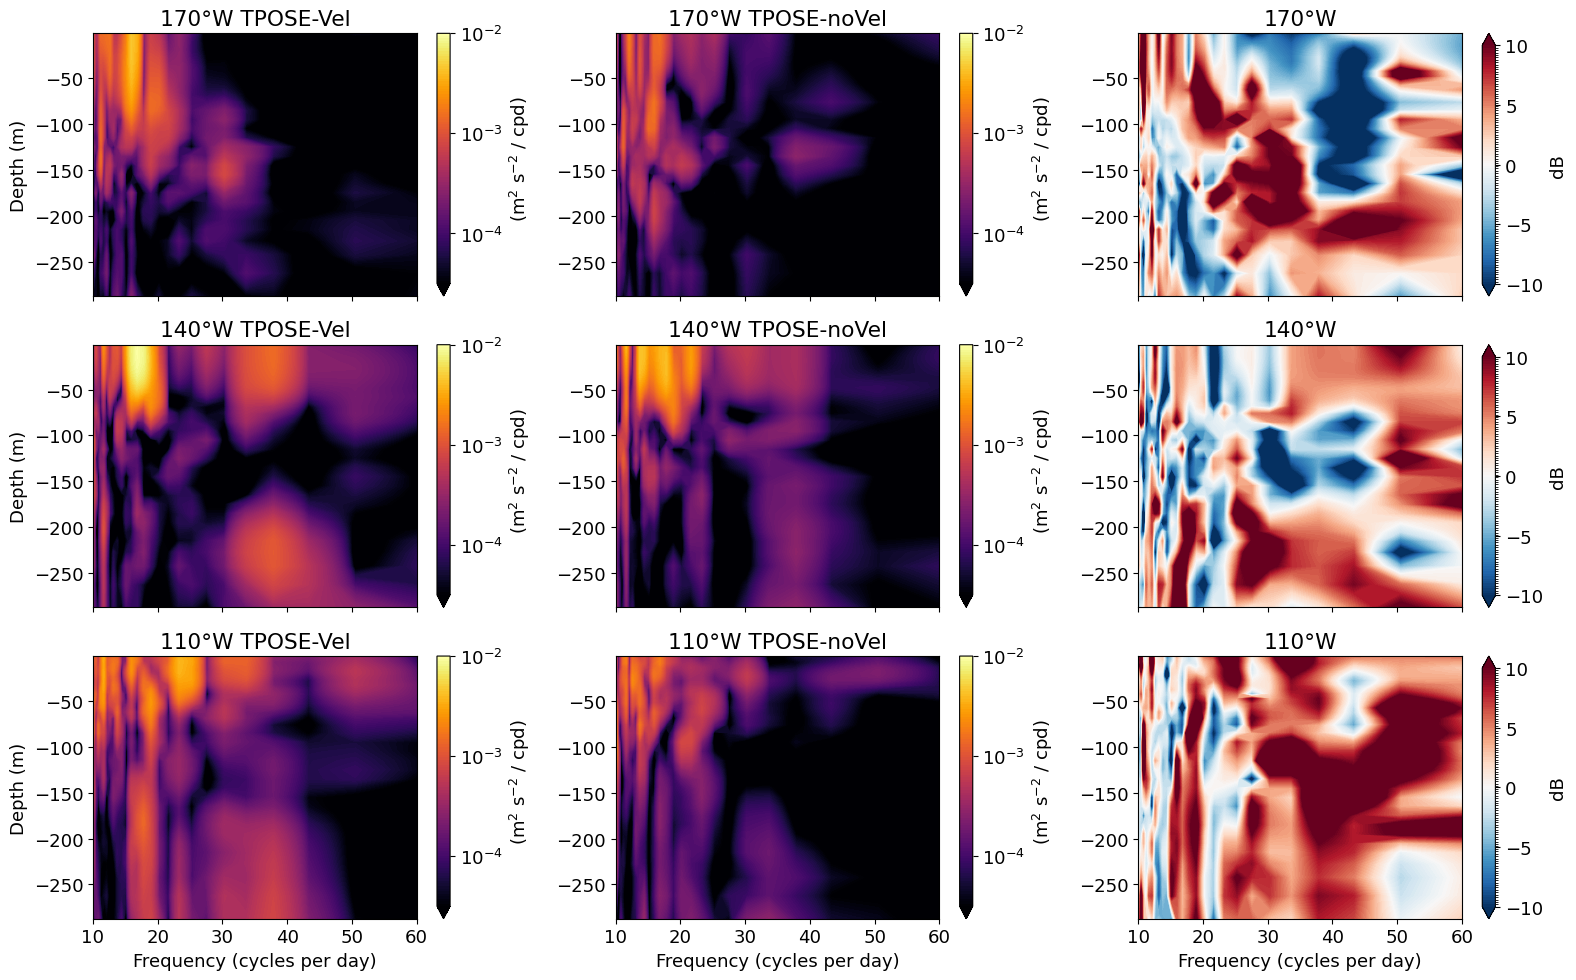

In [100]:

from matplotlib.colors import LogNorm
lons = [190.0, 220.0, 250.0]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 10), sharex=True)
# log_levels = np.logspace(-5, -2, 50)
# norm = LogNorm(vmin=vmin, vmax=vmax)
# levels = np.linspace(1e-5,1e-3,100)
levels = np.logspace(-4.5, -2, 100)
cbar_kwargs={
        'ticks': ticker.LogLocator(base=10, subs=[1.0]),  # ticks at 10^n
        'format': ticker.LogFormatterMathtext(),           # renders as 10^n
        'label': '(m$^2$ s$^{-2}$ / cpd)'
    }
db_levels = np.linspace(-10,10,100)

for lon, ax in zip(lons,axes.flatten()[::3]):
    _, _, psd, _, freq_dpc = psd_for_plot_2d(VVEL.sel(YC=0,XC=lon,method='nearest').sel(Z=slice(0,-300)))
    z_levels = VVEL.sel(YC=0, XC=lon, method='nearest').sel(Z=slice(0,-300)).Z.values
    psd_v = xr.DataArray(psd[1:],dims=['freq', 'Z'],coords={'freq': freq_dpc[1:],'Z': z_levels})
    psd_v.plot.contourf(levels=levels,x='freq', y='Z', ax=ax, cmap='inferno', norm=LogNorm(vmin=levels.min(), vmax=levels.max()),cbar_kwargs=cbar_kwargs)
    ax.set_xlim(10,60)
    ax.set_xlabel('')
    ax.set_ylabel('Depth (m)')
    ax.set_title('{}°W TPOSE-Vel'.format(abs(int(lon-360))))

for lon, ax in zip(lons,axes.flatten()[1::3]):
    _, _, psd_noTAO, _, freq_dpc = psd_for_plot_2d(VVEL_noTAO.sel(YC=0,XC=lon,method='nearest').sel(Z=slice(0,-300)))
    z_levels = VVEL.sel(YC=0, XC=lon, method='nearest').sel(Z=slice(0,-300)).Z.values
    psd_v_noTAO = xr.DataArray(psd_noTAO[1:],dims=['freq', 'Z'],coords={'freq': freq_dpc[1:],'Z': z_levels})
    psd_v_noTAO.plot.contourf(levels=levels,x='freq', y='Z', ax=ax, cmap='inferno',norm=LogNorm(vmin=levels.min(), vmax=levels.max()),cbar_kwargs=cbar_kwargs)
    ax.set_xlim(10,60)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title('{}°W TPOSE-noVel'.format(abs(int(lon-360))))

for lon, ax in zip(lons,axes.flatten()[2::3]):
    _, _, psd_b, _, freq_dpc = psd_for_plot_2d(VVEL.sel(YC=0,XC=lon,method='nearest').sel(Z=slice(0,-300)))
    _, _, psd_a, _, freq_dpc = psd_for_plot_2d(VVEL_noTAO.sel(YC=0,XC=lon,method='nearest').sel(Z=slice(0,-300)))
    psd_ratio = 10 * np.log10(psd_b / psd_a)
    z_levels = VVEL.sel(YC=0, XC=lon, method='nearest').sel(Z=slice(0,-300)).Z.values
    psd_ratio = xr.DataArray(psd_ratio[1:],dims=['freq', 'Z'],coords={'freq': freq_dpc[1:],'Z': z_levels})
    psd_ratio.plot.contourf(levels=db_levels,x='freq', y='Z', ax=ax, cmap='RdBu_r', vmin=-10, vmax=10, cbar_kwargs={'label': 'dB','ticks': np.arange(-10, 11, 5)})
    ax.set_xlim(10,60)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title('{}°W'.format(abs(int(lon-360))))

axes[2,0].set_xlabel('Frequency (cycles per day)')
axes[2,1].set_xlabel('Frequency (cycles per day)')
axes[2,2].set_xlabel('Frequency (cycles per day)')

plt.tight_layout()
fig.savefig(foldername + 'psd_v_3lon_dB.png',dpi=300)

/tmp/ipykernel_715397/3788316874.py:19: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_715397/3788316874.py:19: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_715397/3788316874.py:19: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_715397/3788316874.py:19: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_715397/3788316874.py:19: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_715397/3788316874.py:19: RuntimeWarning: divide by zero encountered in divide
  freq_dpc = 1/(freq_hz * 86400)        # cycles per day
/tmp/ipykernel_715397/3788316874.py:19: RuntimeWarning: divide by zero encountered in divide
  freq_

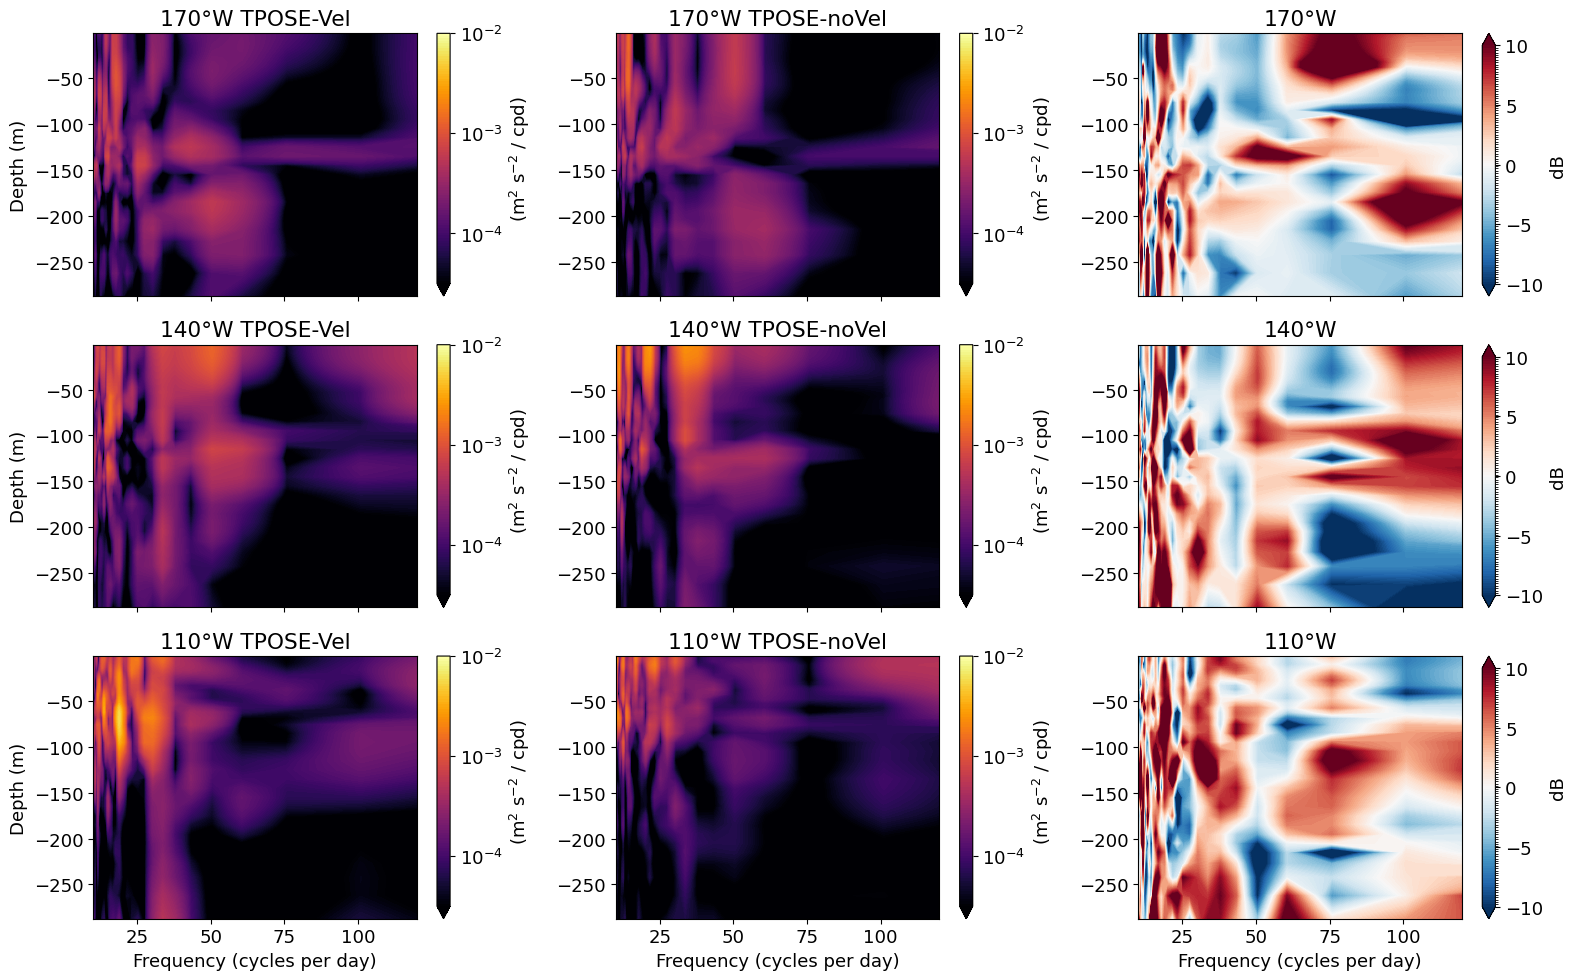

2026-04-02 16:00:16,960 - tornado.application - ERROR - Exception in callback functools.partial(<function TCPServer._handle_connection.<locals>.<lambda> at 0x7f868d91df80>, <Task finished name='Task-1368829' coro=<BaseTCPListener._handle_stream() done, defined at /home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/distributed/comm/tcp.py:655> exception=MemoryError((7002586286238287176,), dtype('uint8'))>)
Traceback (most recent call last):
  File "/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/tornado/tcpserver.py", line 387, in <lambda>
    gen.convert_yielded(future), lambda f: f.result()
                                           ^^^^^^^^^^
  File "/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/distributed/comm/tcp.py", line 667, in _handle_stream
    await self.o

In [101]:

from matplotlib.colors import LogNorm
lons = [190.0, 220.0, 250.0]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 10), sharex=True)
# log_levels = np.logspace(-5, -2, 50)
# norm = LogNorm(vmin=vmin, vmax=vmax)
# levels = np.linspace(1e-5,1e-3,100)
levels = np.logspace(-4.5, -2, 100)
cbar_kwargs={
        'ticks': ticker.LogLocator(base=10, subs=[1.0]),  # ticks at 10^n
        'format': ticker.LogFormatterMathtext(),           # renders as 10^n
        'label': '(m$^2$ s$^{-2}$ / cpd)'
    }
db_levels = np.linspace(-10,10,100)

for lon, ax in zip(lons,axes.flatten()[::3]):
    _, _, psd, _, freq_dpc = psd_for_plot_2d(UVEL.sel(YC=0,XC=lon,method='nearest').sel(Z=slice(0,-300)))
    z_levels = UVEL.sel(YC=0, XC=lon, method='nearest').sel(Z=slice(0,-300)).Z.values
    psd_v = xr.DataArray(psd[1:],dims=['freq', 'Z'],coords={'freq': freq_dpc[1:],'Z': z_levels})
    psd_v.plot.contourf(levels=levels,x='freq', y='Z', ax=ax, cmap='inferno', norm=LogNorm(vmin=levels.min(), vmax=levels.max()),cbar_kwargs=cbar_kwargs)
    ax.set_xlim(10,120)
    ax.set_xlabel('')
    ax.set_ylabel('Depth (m)')
    ax.set_title('{}°W TPOSE-Vel'.format(abs(int(lon-360))))

for lon, ax in zip(lons,axes.flatten()[1::3]):
    _, _, psd_noTAO, _, freq_dpc = psd_for_plot_2d(UVEL_noTAO.sel(YC=0,XC=lon,method='nearest').sel(Z=slice(0,-300)))
    z_levels = UVEL.sel(YC=0, XC=lon, method='nearest').sel(Z=slice(0,-300)).Z.values
    psd_v_noTAO = xr.DataArray(psd_noTAO[1:],dims=['freq', 'Z'],coords={'freq': freq_dpc[1:],'Z': z_levels})
    psd_v_noTAO.plot.contourf(levels=levels,x='freq', y='Z', ax=ax, cmap='inferno',norm=LogNorm(vmin=levels.min(), vmax=levels.max()),cbar_kwargs=cbar_kwargs)
    ax.set_xlim(10,120)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title('{}°W TPOSE-noVel'.format(abs(int(lon-360))))

for lon, ax in zip(lons,axes.flatten()[2::3]):
    _, _, psd_b, _, freq_dpc = psd_for_plot_2d(UVEL.sel(YC=0,XC=lon,method='nearest').sel(Z=slice(0,-300)))
    _, _, psd_a, _, freq_dpc = psd_for_plot_2d(UVEL_noTAO.sel(YC=0,XC=lon,method='nearest').sel(Z=slice(0,-300)))
    psd_ratio = 10 * np.log10(psd_b / psd_a)
    z_levels = UVEL.sel(YC=0, XC=lon, method='nearest').sel(Z=slice(0,-300)).Z.values
    psd_ratio = xr.DataArray(psd_ratio[1:],dims=['freq', 'Z'],coords={'freq': freq_dpc[1:],'Z': z_levels})
    psd_ratio.plot.contourf(levels=db_levels,x='freq', y='Z', ax=ax, cmap='RdBu_r', vmin=-10, vmax=10, cbar_kwargs={'label': 'dB','ticks': np.arange(-10, 11, 5)})
    ax.set_xlim(10,120)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title('{}°W'.format(abs(int(lon-360))))

axes[2,0].set_xlabel('Frequency (cycles per day)')
axes[2,1].set_xlabel('Frequency (cycles per day)')
axes[2,2].set_xlabel('Frequency (cycles per day)')

plt.tight_layout()
fig.savefig(foldername + 'psd_u_3lon_dB.png',dpi=300)

## Other experimental plots

In [8]:
from scipy import signal
def filter_psd_uvel_1d(X, Z):
    # filtering out high frequency changes
    fs = 1/86400 # sampling rate is 1 day (86400 seconds per day)
    highF = (1/10)*fs #  (1 cycle /35 days) * (1 day/86400 second)
    cutoff = np.array(highF)
    order = 4
    sos = signal.butter(order, cutoff, 'lowpass', fs=fs, output='sos')

    uvel_detrend = signal.detrend(UVEL.sel(YC=0.0, XC=X, Z=Z, method='nearest'), axis=0)
    uvel_filt = signal.sosfiltfilt(sos, uvel_detrend, axis=0)
    uvel_detrend_noTAO = signal.sosfiltfilt(sos, UVEL_noTAO.sel(YC=0.0, XC=X, Z=Z, method='nearest'), axis=0)
    uvel_filt_noTAO = signal.sosfiltfilt(sos, uvel_detrend_noTAO, axis=0)

    uvel_filt = xr.DataArray(
        uvel_filt,
        dims=('time'),
        coords={'time': UVEL.sel(YC=0.0, XC=X, Z=Z, method='nearest').time},
    )

    uvel_filt_noTAO = xr.DataArray(
        uvel_filt_noTAO,
        dims=('time'),
        coords={'time': UVEL_noTAO.sel(YC=0.0, XC=X, Z=Z, method='nearest').time},
    )

    _, _, psd, _, freq_dpc = psd_for_plot_1d(uvel_filt)
    _, _, psd_noTAO, _, freq_dpc = psd_for_plot_1d(uvel_filt_noTAO)

    return psd, psd_noTAO, freq_dpc

def filter_psd_vvel_1d(X, Z):
    # filtering out high frequency changes
    fs = 1/86400 # sampling rate is 1 day (86400 seconds per day)
    highF = (1/10)*fs #  (1 cycle /35 days) * (1 day/86400 second)
    cutoff = np.array(highF)
    order = 4
    sos = signal.butter(order, cutoff, 'lowpass', fs=fs, output='sos')

    vvel_detrend = signal.detrend(VVEL.sel(YC=0.0, XC=X, Z=Z, method='nearest'), axis=0)
    vvel_filt = signal.sosfiltfilt(sos, vvel_detrend, axis=0)
    vvel_detrend_noTAO = signal.sosfiltfilt(sos, VVEL_noTAO.sel(YC=0.0, XC=X, Z=Z, method='nearest'), axis=0)
    vvel_filt_noTAO = signal.sosfiltfilt(sos, vvel_detrend_noTAO, axis=0)

    vvel_filt = xr.DataArray(
        vvel_filt,
        dims=('time'),
        coords={'time': VVEL.sel(YC=0.0, XC=X, Z=Z, method='nearest').time},
    )

    vvel_filt_noTAO = xr.DataArray(
        vvel_filt_noTAO,
        dims=('time'),
        coords={'time': VVEL_noTAO.sel(YC=0.0, XC=X, Z=Z, method='nearest').time},
    )

    _, _, psd, _, freq_dpc = psd_for_plot_1d(vvel_filt)
    _, _, psd_noTAO, _, freq_dpc = psd_for_plot_1d(vvel_filt_noTAO)

    return psd, psd_noTAO, freq_dpc


In [ ]:
fig, ax = plt.subplots(figsize=(6,8))
psd, psd_noTAO, freq_dpc = filter_psd_uvel_1d(X=220.0, Z=-50.0)
ax.plot(freq_dpc, psd,label='50m, TAO')
ax.plot(freq_dpc, psd_noTAO,label='50m, No TAO')
psd, psd_noTAO, freq_dpc = filter_psd_uvel_1d(X=220.0, Z=-100.0)
ax.plot(freq_dpc, psd,label='100m, TAO',color='C0',linestyle='--')
ax.plot(freq_dpc, psd_noTAO,label='100m, No TAO',color='C1',linestyle='--')
psd, psd_noTAO, freq_dpc = filter_psd_uvel_1d(X=220.0, Z=-150.0)
ax.plot(freq_dpc, psd,label='150m, TAO',color='C0',linestyle=':')
ax.plot(freq_dpc, psd_noTAO,label='150m, No TAO',color='C1',linestyle=':')
ax.legend()
ax.set_xlabel('Frequency (cycles per day)')
ax.set_ylabel('Power (m$^2$/s$^2$/cpd)')
ax.loglog()
ax.set_xlim(2,150)
fig.savefig(foldername + 'U_power_spectrum_140W.png',dpi=300)

In [ ]:
fig, axes = plt.subplots(figsize=(10,10),nrows=3)

for ax, lon in zip(axes,[190, 220, 250]):
    psd, psd_noTAO, freq_dpc = filter_psd_uvel_1d(X=lon, Z=-50.0)
    ax.plot(freq_dpc, psd,label='50m, TAO')
    ax.plot(freq_dpc, psd_noTAO,label='50m, No TAO')
    psd, psd_noTAO, freq_dpc = filter_psd_uvel_1d(X=lon, Z=-100.0)
    ax.plot(freq_dpc, psd,label='100m, TAO',color='C0',linestyle='--')
    ax.plot(freq_dpc, psd_noTAO,label='100m, No TAO',color='C1',linestyle='--')
    psd, psd_noTAO, freq_dpc = filter_psd_uvel_1d(X=lon, Z=-150.0)
    ax.plot(freq_dpc, psd,label='150m, TAO',color='C0',linestyle=':')
    ax.plot(freq_dpc, psd_noTAO,label='150m, No TAO',color='C1',linestyle=':')
    ax.set_xlabel('')
    ax.set_ylabel('Power (m$^2$/s$^2$/cpd)')
    ax.set_title(f'0N, {np.abs(lon-360):.0f}W')
    ax.set_xlim(2,150)
    ax.loglog()

axes[0].legend(loc='lower right',ncol=2,fontsize=11)
axes[2].set_xlabel('Frequency (cycles per day)')
plt.tight_layout()
fig.savefig(foldername + 'U_power_spectrum.png',dpi=300)

In [ ]:
fig, axes = plt.subplots(figsize=(16,10),nrows=3,ncols=2)

for ax, lon in zip(axes.flatten()[0::2],[190, 220, 250]):
    psd, psd_noTAO, freq_dpc = filter_psd_uvel_1d(X=lon, Z=-50.0)
    ax.plot(freq_dpc, psd,label='50m, TAO')
    ax.plot(freq_dpc, psd_noTAO,label='50m, No TAO')
    psd, psd_noTAO, freq_dpc = filter_psd_uvel_1d(X=lon, Z=-100.0)
    ax.plot(freq_dpc, psd,label='100m, TAO',color='C0',linestyle='--')
    ax.plot(freq_dpc, psd_noTAO,label='100m, No TAO',color='C1',linestyle='--')
    psd, psd_noTAO, freq_dpc = filter_psd_uvel_1d(X=lon, Z=-150.0)
    ax.plot(freq_dpc, psd,label='150m, TAO',color='C0',linestyle=':')
    ax.plot(freq_dpc, psd_noTAO,label='150m, No TAO',color='C1',linestyle=':')
    ax.set_xlabel('')
    ax.set_ylabel('Power (m$^2$/s$^2$/cpd)')
    ax.set_title(f'0N, {np.abs(lon-360):.0f}W U')
    ax.loglog()
    ax.set_xlim(10,150)
    ax.set_ylim(1e-7,1e-2)

for ax, lon in zip(axes.flatten()[1::2],[190, 220, 250]):
    psd, psd_noTAO, freq_dpc = filter_psd_vvel_1d(X=lon, Z=-50.0)
    ax.plot(freq_dpc, psd,label='50m, TAO')
    ax.plot(freq_dpc, psd_noTAO,label='50m, No TAO')
    psd, psd_noTAO, freq_dpc = filter_psd_vvel_1d(X=lon, Z=-100.0)
    ax.plot(freq_dpc, psd,label='100m, TAO',color='C0',linestyle='--')
    ax.plot(freq_dpc, psd_noTAO,label='100m, No TAO',color='C1',linestyle='--')
    psd, psd_noTAO, freq_dpc = filter_psd_vvel_1d(X=lon, Z=-150.0)
    ax.plot(freq_dpc, psd,label='150m, TAO',color='C0',linestyle=':')
    ax.plot(freq_dpc, psd_noTAO,label='150m, No TAO',color='C1',linestyle=':')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(f'0N, {np.abs(lon-360):.0f}W V')
    ax.loglog()
    ax.set_xlim(10,150)
    ax.set_ylim(1e-7,1e-2)

axes[0,0].legend(loc='lower right',ncol=3,fontsize=11)
axes[2,0].set_xlabel('Frequency (cycles per day)')
axes[2,1].set_xlabel('Frequency (cycles per day)')
plt.tight_layout()
fig.savefig(foldername + 'UV_power_spectrum_10day.png',dpi=300)

In [14]:
grid = xgcm.Grid(ds_tpose_TAO, periodic=False)

# create grid
target_values = np.arange(14, 23.5, 0.1)

theta_interp = grid.interp(ds_tpose_TAO.THETA, 'X', boundary='fill')
UVEL_theta = grid.transform(ds_tpose_TAO.UVEL, axis='Z', target=target_values, target_data=theta_interp, method='linear').transpose('time','THETA','YC','XG')
theta_interp = grid.interp(ds_tpose_TAO.THETA, 'Y', boundary='fill')
VVEL_theta = grid.transform(ds_tpose_TAO.VVEL, axis='Z', target=target_values, target_data=theta_interp, method='linear').transpose('time','THETA','YG','XC')

grid = xgcm.Grid(ds_tpose_noTAO, periodic=False)
theta_interp = grid.interp(ds_tpose_noTAO.THETA, 'X', boundary='fill')
UVEL_noTAO_theta = grid.transform(ds_tpose_noTAO.UVEL, axis='Z', target=target_values, target_data=theta_interp, method='linear').transpose('time','THETA','YC','XG')
theta_interp = grid.interp(ds_tpose_noTAO.THETA, 'Y', boundary='fill')
VVEL_noTAO_theta = grid.transform(ds_tpose_noTAO.VVEL, axis='Z', target=target_values, target_data=theta_interp, method='linear').transpose('time','THETA','YG','XC')

In [19]:
from scipy import signal
def filter_psd_uvel_isotherm(X, T):
    # filtering out high frequency changes
    fs = 1/86400 # sampling rate is 1 day (86400 seconds per day)
    highF = (1/10)*fs #  (1 cycle /35 days) * (1 day/86400 second)
    cutoff = np.array(highF)
    order = 4
    sos = signal.butter(order, cutoff, 'lowpass', fs=fs, output='sos')

    uvel_detrend = signal.detrend(UVEL_theta.sel(YC=0.0, XG=X, THETA=T, method='nearest'), axis=0)
    uvel_filt = signal.sosfiltfilt(sos, uvel_detrend, axis=0)
    uvel_detrend_noTAO = signal.sosfiltfilt(sos, UVEL_noTAO_theta.sel(YC=0.0, XG=X, THETA=T, method='nearest'), axis=0)
    uvel_filt_noTAO = signal.sosfiltfilt(sos, uvel_detrend_noTAO, axis=0)

    uvel_filt = xr.DataArray(
        uvel_filt,
        dims=('time'),
        coords={'time': UVEL_theta.sel(YC=0.0, XG=X, THETA=T, method='nearest').time},
    )

    uvel_filt_noTAO = xr.DataArray(
        uvel_filt_noTAO,
        dims=('time'),
        coords={'time': UVEL_noTAO_theta.sel(YC=0.0, XG=X, THETA=T, method='nearest').time},
    )

    _, _, psd, _, freq_dpc = psd_for_plot_1d(uvel_filt)
    _, _, psd_noTAO, _, freq_dpc = psd_for_plot_1d(uvel_filt_noTAO)

    return psd, psd_noTAO, freq_dpc

def filter_psd_vvel_isotherm(X, T):
    # filtering out high frequency changes
    fs = 1/86400 # sampling rate is 1 day (86400 seconds per day)
    highF = (1/10)*fs #  (1 cycle /35 days) * (1 day/86400 second)
    cutoff = np.array(highF)
    order = 4
    sos = signal.butter(order, cutoff, 'lowpass', fs=fs, output='sos')

    vvel_detrend = signal.detrend(VVEL_theta.sel(YC=0.0, XC=X, THETA=T, method='nearest'), axis=0)
    vvel_filt = signal.sosfiltfilt(sos, vvel_detrend, axis=0)
    vvel_detrend_noTAO = signal.sosfiltfilt(sos, VVEL_noTAO_theta.sel(YC=0.0, XC=X, THETA=T, method='nearest'), axis=0)
    vvel_filt_noTAO = signal.sosfiltfilt(sos, vvel_detrend_noTAO, axis=0)

    vvel_filt = xr.DataArray(
        vvel_filt,
        dims=('time'),
        coords={'time': VVEL_theta.sel(YC=0.0, XC=X, THETA=T, method='nearest').time},
    )

    vvel_filt_noTAO = xr.DataArray(
        vvel_filt_noTAO,
        dims=('time'),
        coords={'time': VVEL_noTAO_theta.sel(YC=0.0, XC=X, THETA=T, method='nearest').time},
    )

    _, _, psd, _, freq_dpc = psd_for_plot_1d(vvel_filt)
    _, _, psd_noTAO, _, freq_dpc = psd_for_plot_1d(vvel_filt_noTAO)

    return psd, psd_noTAO, freq_dpc


In [ ]:
fig, axes = plt.subplots(figsize=(16,10),nrows=3,ncols=2)

for ax, lon in zip(axes.flatten()[0::2],[190, 220, 250]):
    psd, psd_noTAO, freq_dpc = filter_psd_uvel_isotherm(X=lon, T=23.0)
    ax.plot(freq_dpc, psd,label='23deg, TAO')
    ax.plot(freq_dpc, psd_noTAO,label='23deg, No TAO')
    psd, psd_noTAO, freq_dpc = filter_psd_uvel_isotherm(X=lon, T=20.0)
    ax.plot(freq_dpc, psd,label='20deg, TAO',color='C0',linestyle='--')
    ax.plot(freq_dpc, psd_noTAO,label='20deg, No TAO',color='C1',linestyle='--')
    psd, psd_noTAO, freq_dpc = filter_psd_uvel_isotherm(X=lon, T=17.0)
    ax.plot(freq_dpc, psd,label='17deg, TAO',color='C0',linestyle=':')
    ax.plot(freq_dpc, psd_noTAO,label='17deg, No TAO',color='C1',linestyle=':')
    ax.set_xlabel('')
    ax.set_ylabel('Power (m$^2$/s$^2$/cpd)')
    ax.set_title(f'0N, {np.abs(lon-360):.0f}W U')
    ax.loglog()
    ax.set_xlim(10,150)
    ax.set_ylim(1e-7,1e-2)

for ax, lon in zip(axes.flatten()[1::2],[190, 220, 250]):
    psd, psd_noTAO, freq_dpc = filter_psd_vvel_isotherm(X=lon, T=23.0)
    ax.plot(freq_dpc, psd,label='23deg, TAO')
    ax.plot(freq_dpc, psd_noTAO,label='23deg, No TAO')
    psd, psd_noTAO, freq_dpc = filter_psd_vvel_isotherm(X=lon, T=20.0)
    ax.plot(freq_dpc, psd,label='20deg, TAO',color='C0',linestyle='--')
    ax.plot(freq_dpc, psd_noTAO,label='20deg, No TAO',color='C1',linestyle='--')
    psd, psd_noTAO, freq_dpc = filter_psd_vvel_isotherm(X=lon, T=17.0)
    ax.plot(freq_dpc, psd,label='17deg, TAO',color='C0',linestyle=':')
    ax.plot(freq_dpc, psd_noTAO,label='17deg, No TAO',color='C1',linestyle=':')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(f'0N, {np.abs(lon-360):.0f}W V')
    ax.loglog()
    ax.set_xlim(10,150)
    ax.set_ylim(1e-7,1e-2)

axes[0,0].legend(loc='lower right',ncol=3,fontsize=11)
axes[2,0].set_xlabel('Frequency (cycles per day)')
axes[2,1].set_xlabel('Frequency (cycles per day)')
plt.tight_layout()
fig.savefig(foldername + 'UV_power_spectrum_isotherm.png',dpi=300)

In [ ]:
client.shutdown()
cluster.close()
client.close()